In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
from vasicek_poisson.config import RAW_DATA_DIR, AAA_FILENAME
from vasicek_poisson.data.loader import ECBDataLoader

loader = ECBDataLoader(RAW_DATA_DIR)
df = loader.load_csv(AAA_FILENAME)

df.head()
df.columns
df["DATA_TYPE_FM"].unique()


<StringArray>
[    'BETA0',     'BETA1',     'BETA2',     'BETA3',    'IF_10M',    'IF_10Y',
 'IF_10Y10M', 'IF_10Y11M',  'IF_10Y1M',  'IF_10Y2M',
 ...
   'SR_9Y2M',   'SR_9Y3M',   'SR_9Y4M',   'SR_9Y5M',   'SR_9Y6M',   'SR_9Y7M',
   'SR_9Y8M',   'SR_9Y9M',      'TAU1',      'TAU2']
Length: 1083, dtype: str

In [10]:
from vasicek_poisson.config import RAW_DATA_DIR, AAA_FILENAME, ALL_BONDS_FILENAME
from vasicek_poisson.data.loader import ECBDataLoader
from vasicek_poisson.data.parser import ECBDataParser

loader = ECBDataLoader(RAW_DATA_DIR)
parser = ECBDataParser()

df_aaa, df_all = loader.load_pair(AAA_FILENAME, ALL_BONDS_FILENAME)

aaa_spot = parser.keep_core_columns(parser.filter_spot_rates(df_aaa))
aaa_spot = parser.add_maturity_years(aaa_spot)

aaa_spot.head()

aaa_spot.columns
aaa_spot.shape
aaa_spot["maturity_years"].unique()
aaa_spot["TIME_PERIOD"].unique()[:10]

# now for the all bonds dataset
all_bonds_spot = parser.keep_core_columns(parser.filter_spot_rates(df_all))
all_bonds_spot = parser.add_maturity_years(all_bonds_spot)
all_bonds_spot.head()

all_bonds_spot.columns
all_bonds_spot.shape
all_bonds_spot["maturity_years"].unique()
all_bonds_spot["TIME_PERIOD"].unique()[:10]

<StringArray>
['2026-01-02', '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
 '2026-01-09', '2026-01-12', '2026-01-13', '2026-01-14', '2026-01-15']
Length: 10, dtype: str

In [8]:
#visutalize the entire df as spreadsheet
aaa_spot.head(20)


,TIME_PERIOD,DATA_TYPE_FM,OBS_VALUE,TITLE,maturity_years
32535,2026-01-02,SR_10M,2.000932,"Yield curve spot rate, 10-month residual maturity - Government bond, nominal, all issuers whose rating is triple A - Euro area (changing composition)",0.833333
32536,2026-01-05,SR_10M,2.006473,"Yield curve spot rate, 10-month residual maturity - Government bond, nominal, all issuers whose rating is triple A - Euro area (changing composition)",0.833333
32537,2026-01-06,SR_10M,1.992168,"Yield curve spot rate, 10-month residual maturity - Government bond, nominal, all issuers whose rating is triple A - Euro area (changing composition)",0.833333
32538,2026-01-07,SR_10M,1.987753,"Yield curve spot rate, 10-month residual maturity - Government bond, nominal, all issuers whose rating is triple A - Euro area (changing composition)",0.833333
32539,2026-01-08,SR_10M,1.986953,"Yield curve spot rate, 10-month residual maturity - Government bond, nominal, all issuers whose rating is triple A - Euro area (changing composition)",0.833333
32540,2026-01-09,SR_10M,2.003730,"Yield curve spot rate, 10-month residual maturity - Government bond, nominal, all issuers whose rating is triple A - Euro area (changing composition)",0.833333
32541,2026-01-12,SR_10M,1.999650,"Yield curve spot rate, 10-month residual maturity - Government bond, nominal, all issuers whose rating is triple A - Euro area (changing composition)",0.833333
32542,2026-01-13,SR_10M,2.000539,"Yield curve spot rate, 10-month residual maturity - Government bond, nominal, all issuers whose rating is triple A - Euro area (changing composition)",0.833333
32543,2026-01-14,SR_10M,1.989242,"Yield curve spot rate, 10-month residual maturity - Government bond, nominal, all issuers whose rating is triple A - Euro area (changing composition)",0.833333
32544,2026-01-15,SR_10M,1.994876,"Yield curve spot rate, 10-month residual maturity - Government bond, nominal, all issuers whose rating is triple A - Euro area (changing composition)",0.833333


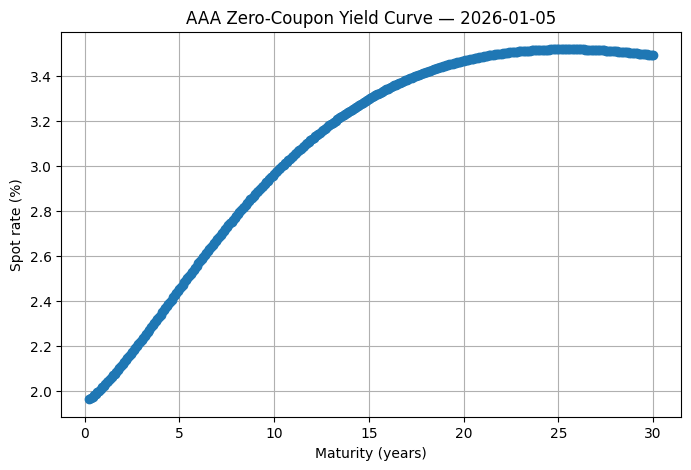

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# ensure date is datetime
aaa_spot["TIME_PERIOD"] = pd.to_datetime(aaa_spot["TIME_PERIOD"])

# choose a date (must exist in dataset)
date = pd.Timestamp("2026-01-05")

# slice curve
curve = aaa_spot[aaa_spot["TIME_PERIOD"] == date]

# sort by maturity
curve = curve.sort_values("maturity_years")

# plot
plt.figure(figsize=(8,5))
plt.plot(curve["maturity_years"], curve["OBS_VALUE"], marker="o")
plt.xlabel("Maturity (years)")
plt.ylabel("Spot rate (%)")
plt.title(f"AAA Zero-Coupon Yield Curve — {date.date()}")
plt.grid(True)
plt.show()

In [19]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_two_curves(df_aaa, df_all, date):
    date = pd.Timestamp(date)

    df_aaa = df_aaa.copy()
    df_all = df_all.copy()

    df_aaa["TIME_PERIOD"] = pd.to_datetime(df_aaa["TIME_PERIOD"])
    df_all["TIME_PERIOD"] = pd.to_datetime(df_all["TIME_PERIOD"])

    curve_aaa = df_aaa[df_aaa["TIME_PERIOD"] == date].sort_values("maturity_years")
    curve_all = df_all[df_all["TIME_PERIOD"] == date].sort_values("maturity_years")

    print("AAA points:", len(curve_aaa))
    print("ALL points:", len(curve_all))

    plt.figure(figsize=(9, 5))
    plt.plot(curve_aaa["maturity_years"], curve_aaa["OBS_VALUE"], marker="o", label="AAA")
    plt.plot(curve_all["maturity_years"], curve_all["OBS_VALUE"], marker="o", label="Aggregate")
    plt.xlabel("Maturity (years)")
    plt.ylabel("Spot rate (%)")
    plt.title(f"ECB Zero-Coupon Yield Curves — {date.date()}")
    plt.legend()
    plt.grid(True)
    plt.show()

AAA points: 358
ALL points: 358


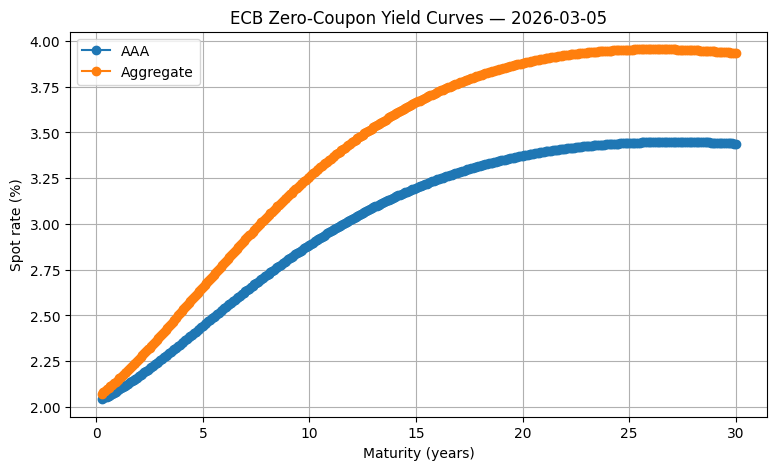

In [35]:
plot_two_curves(aaa_spot, all_bonds_spot, "2026-03-05")